## Notebook 04 — Baseline Recommenders & Evaluation (MIND-small)

this notebook trains to find:

- what is more popular
- what a certain user likes

Them DEV is used to test:

- given the options that were recommended to this user, using our scoring sistem (popularity or user preference) what would we recommed among these options, (since we cannot change the real world and make the user chose among options he didn't have)

- so we rank the options that were given to the user and then we see if the scoring rule learned from TRAIN is aligned with the user's preferences in a generelizable way.

- Basically if the user "clicks near the top" of the ranking it's a way of confirming that the ranking rule was useful. (the recommendation algorithm is doing it's job.) If we had been the system ordering the list, we would likely have put the clicked item near the top, which is what a good recommender should do.

------------------------

Accuracy in these notebook means:

When the user had 30–40 options, did our ranking put the option they actually chose closer to the top than the other options?

- If yes → the model is good at prioritizing things the user tends to click.

- If no → the model is basically random/useless.
------------------------------------

To evaluate any recommender, we need some outcome that tells us what the user preferred.

In this dataset, the only reliable preference signal is:

- clicked vs not clicked

So we use clicks as a proxy for “relevant”.

------------------

So basically in this notebook we want to test : Given the candidates the user saw, would our model rank the clicked ones near the top (accuracy), and would that ranking concentrate political content for political users (reinforcement potential)?

----------------------------------
In Notebook 03 we profiled the logs and found:
- **Political content is present** and has measurable engagement.
- **Popularity concentration is extreme** (very small “head” of items dominates exposure and clicks).

Now I need a *working recommendation + evaluation loop* so I can later test:
1. **Reinforcement**: do personalized recommendations increase the share of political (or left/center/right) items shown to some users?
2. **Mitigation**: can we reduce over‑concentration (or ideological skew) with re-ranking while keeping ranking quality acceptable?

### Outputs to expect
- Ranking quality for each baseline: **MRR@10** and **nDCG@10** on the DEV split.
- A “reinforcement proxy”: **politics share in Top‑10 recommendations** for:
  - politically engaged users (≥3 political clicks in TRAIN) vs others
  - popularity vs personalized baseline

> **Important:** At this stage I'm not proving causal bias. I'm building baselines + measuring *descriptive differences* that can motivate fairness / mitigation experiments.

### Imports

In [67]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Path

In [36]:
PROJECT = Path().resolve().parent
PROCESSED = PROJECT / "data" / "processed"

### Load 

In [37]:
clicks_train = pd.read_pickle(PROCESSED / "clicks_train.pkl")
news_train   = pd.read_pickle(PROCESSED / "news_train.pkl")

clicks_dev = pd.read_pickle(PROCESSED / "clicks_dev.pkl")
news_dev   = pd.read_pickle(PROCESSED / "news_dev.pkl")

print("train clicks:", clicks_train.shape, "train news:", news_train.shape)
print("dev clicks:", clicks_dev.shape, "dev news:", news_dev.shape)

train clicks: (5843444, 9) train news: (51282, 8)
dev clicks: (2740998, 9) dev news: (42416, 8)


### Define politics + politically engaged users

Here `is_politics` is defined using subcategory and then “politically engaged users” is defined as users with ≥3 political clicks in TRAIN. We only use TRAIN for defining engagement to avoid “peeking” into DEV.

In [38]:
# politics flag from TRAIN news
news_train["is_politics"] = news_train["subcategory"].str.contains("polit", case=False, na=False)
polit_ids_train = set(news_train.loc[news_train["is_politics"], "news_id"])

clicks_train["is_politics"] = clicks_train["news_id"].isin(polit_ids_train)

# political clicks per user in TRAIN
pol_clicks_per_user = (
    clicks_train.loc[(clicks_train["clicked"]==1) & (clicks_train["is_politics"])]
    .groupby("user_id").size()
)

engaged_users = set(pol_clicks_per_user[pol_clicks_per_user >= 3].index)

print("Politically engaged users (>=3 political clicks):", len(engaged_users))


Politically engaged users (>=3 political clicks): 627


This code labels political articles, counts political clicks per user in TRAIN, and defines “politically engaged users” as those with ≥3 political clicks.

### Build DEV ground truth per impression

In [39]:
dev_groups = clicks_dev.groupby("impression_id")

impression_candidates = dev_groups["news_id"].apply(list)
impression_labels = dev_groups["clicked"].apply(list)  # parallel list of 0/1

print("DEV impressions:", len(impression_candidates))


DEV impressions: 73152


this code makes sure we can evaluate impressions ( what options/recomendations of news the user was exposed to at a certain time and which he chose)

### Metrics: MRR@K and nDCG@K

To evaluate ranking quality:

- MRR@K: how early the first clicked item appears (higher is better)

- nDCG@K: rewards putting clicked items near the top (higher is better)

In [40]:
def mrr_at_k(y_true, y_score, k=10):
    # y_true: list of 0/1, y_score: list of scores
    order = np.argsort(-np.array(y_score))[:k]
    for rank, idx in enumerate(order, start=1):
        if y_true[idx] == 1:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(y_true, y_score, k=10):
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    order = np.argsort(-y_score)[:k]
    gains = y_true[order]
    dcg = np.sum(gains / np.log2(np.arange(2, 2 + len(gains))))
    ideal = np.sort(y_true)[::-1][:k]
    idcg = np.sum(ideal / np.log2(np.arange(2, 2 + len(ideal))))
    return float(dcg / idcg) if idcg > 0 else 0.0


**MRR@10 (Mean Reciprocal Rank at 10)**
What it is (super simple)

For each impression:

-look at ranked top-10

- find the rank position of the first clicked item

- score = 1 / rank

    - clicked item at rank 1 → score 1.0

    - rank 2 → 0.5

    - rank 3 → 0.333

    - rank 4 → 0.25

    - rank 5 → 0.20

    - rank 10 → 0.10

    - if no clicked item is in top-10 → 0

Then you average across impressions.

**nDCG@10 (normalized Discounted Cumulative Gain at 10)**

What it is (super simple)

nDCG@10 rewards you for:

- putting clicked items near the top

- and if there are multiple clicks in an impression, ranking all clicked items high

It gives higher weight to top ranks (rank 1 matters more than rank 10).

Range

- 1.0 = perfect ranking (clicked items at the top exactly)

- 0.0 = horrible (clicked items never show in top-10)

### Baseline A: Popularity recommender

Score every candidate/article by how many clicks it got in TRAIN (global popularity). Non-personalized.

In [41]:
pop_clicks = clicks_train.groupby("news_id")["clicked"].sum()
pop_score = pop_clicks.to_dict()


The code above "counts" the click a certain article had (regardless of the user)

In [42]:
def evaluate_baseline(score_fn, k=10, max_impressions=20000):
    mrrs, ndcgs = [], []
    ids = impression_candidates.index[:max_impressions]

    for imp_id in ids:
        cands = impression_candidates[imp_id]
        y_true = impression_labels[imp_id]
        y_score = [score_fn(imp_id, nid) for nid in cands]

        mrrs.append(mrr_at_k(y_true, y_score, k=k))
        ndcgs.append(ndcg_at_k(y_true, y_score, k=k))

    return float(np.mean(mrrs)), float(np.mean(ndcgs))

def pop_score_fn(imp_id, news_id):
    return pop_score.get(news_id, 0.0)

mrr10_pop, ndcg10_pop = evaluate_baseline(pop_score_fn, k=10)
print("Popularity baseline -> MRR@10:", mrr10_pop, "nDCG@10:", ndcg10_pop)


Popularity baseline -> MRR@10: 0.24861329365079363 nDCG@10: 0.30997804528288125


Here we go to each impression (recommendation list given to a user at a given time) and organize each article/candidate based on it's score in the train (popularity). W
hat we conclude from the output,

- MRR@10 ≈ 0.2486 means that, on average, the first clicked item is around rank ~4-ish

- nDCG@10 ≈ 0.3100 clicked items are concentrated toward the top, but far from perfectly ranked.

Given that there exists about ~24–37 candidates in each impression, values like the ones above aren't random.

Popularity ranking is not random: it often places a clicked item in the top 10, and often fairly near the top.

It’s a decent baseline

In [43]:
def hitrate_at_k(y_true, y_score, k=10):
    order = np.argsort(-np.array(y_score))
    topk = order[:k]
    return int(np.any(np.array(y_true)[topk] == 1))

hits = []
for imp_id in impression_candidates.index[:20000]:
    cands = impression_candidates[imp_id]
    y_true = impression_labels[imp_id]
    y_score = [pop_score.get(nid, 0.0) for nid in cands]
    hits.append(hitrate_at_k(y_true, y_score, k=10))

print("HitRate@10 (Popularity):", np.mean(hits))


HitRate@10 (Popularity): 0.61495


In 61% of impressions, the clicked article appears in the top-10 ranking.

By intuiton:

- If there are 24 candidates and 1 click, random chance clicked item is in top-10 is 10/24 ≈ 42%

- If 37 candidates, it’s 10/37 ≈ 27%

So random isn’t “near zero” in this problem. 

### Random Walk

In [55]:
rng = np.random.default_rng(42)

def evaluate_random_baseline(k=10, max_impressions=20000):
    mrrs, ndcgs = [], []
    ids = impression_candidates.index[:max_impressions]

    for imp_id in ids:
        cands = impression_candidates[imp_id]
        y_true = impression_labels[imp_id]

        y_score = rng.random(len(cands)).tolist()  # one random score per candidate
        mrrs.append(mrr_at_k(y_true, y_score, k=k))
        ndcgs.append(ndcg_at_k(y_true, y_score, k=k))

    return float(np.mean(mrrs)), float(np.mean(ndcgs))

mrr10_rand2, ndcg10_rand2 = evaluate_random_baseline(k=10, max_impressions=20000)
print("Random baseline (per-impression) -> MRR@10:", mrr10_rand2, "nDCG@10:", ndcg10_rand2)


Random baseline (per-impression) -> MRR@10: 0.22363386904761906 nDCG@10: 0.283815510179595


These metrics don’t go negative; even random will produce a moderate value when:

- there’s typically a click in each impression,

- and k=10 is large relative to list size.

So your random MRR@10 ≈ 0.224 is plausible.

Popularity is a weak-but-real signal. It helps, but it won’t produce a massive jump over random in every dataset.

We did get an improvement:

- MRR@10: 0.2486 vs 0.2236 (Δ ≈ +0.025)

- nDCG@10: 0.3100 vs 0.2838 (Δ ≈ +0.026)

That’s a meaningful lift in ranking metrics, even if it doesn’t look huge.

In [56]:
def hitrate_at_k(y_true, y_score, k=10):
    order = np.argsort(-np.array(y_score))
    topk = order[:k]
    return float(np.any(np.array(y_true)[topk] == 1))

def evaluate_hitrate(score_fn, k=10, max_impressions=20000):
    hits = []
    ids = impression_candidates.index[:max_impressions]
    for imp_id in ids:
        cands = impression_candidates[imp_id]
        y_true = impression_labels[imp_id]
        y_score = [score_fn(imp_id, nid) for nid in cands]
        hits.append(hitrate_at_k(y_true, y_score, k=k))
    return float(np.mean(hits))

# popularity hitrate
hr_pop = evaluate_hitrate(pop_score_fn, k=10, max_impressions=20000)

# random hitrate (per-impression scores)
rng = np.random.default_rng(42)
def random_score_fn_per_call(imp_id, nid):
    return float(rng.random())
hr_rand = evaluate_hitrate(random_score_fn_per_call, k=10, max_impressions=20000)

print("HitRate@10 Random:", hr_rand)
print("HitRate@10 Popularity:", hr_pop)


HitRate@10 Random: 0.58375
HitRate@10 Popularity: 0.61495


Random is a strong baseline in this setting because each impression contains many candidates and the evaluation metric is HitRate@10 (“at least one clicked item appears in the top-10”). Even a random ordering will frequently place one of the clicked items inside the first ten positions (HitRate@10 = 0.584). However, the popularity baseline learned from training clicks still provides a clear improvement, increasing HitRate@10 to 0.615 (+3.1 pp), which corresponds to ~624 additional impressions (out of 20k) where a clicked item appears in the top-10. Moreover, popularity also improves MRR@10 and nDCG@10, indicating not only more hits but also better placement of clicked items near the top of the ranked list. This confirms that popularity captures meaningful signal beyond chance and serves as a strong reference baseline for later fairness / re-ranking experiments.

### Baseline B: Simple personalization by category preference

I build each user’s most-clicked categories in TRAIN, and score DEV candidates higher if they match those categories.

In [45]:
train_meta = news_train.set_index("news_id")[["category","subcategory"]]

# only use clicked items to build preferences
train_clicks_only = clicks_train.loc[clicks_train["clicked"]==1, ["user_id","news_id"]].copy()
train_clicks_only = train_clicks_only.join(train_meta, on="news_id", how="left")

user_cat_counts = (
    train_clicks_only.groupby(["user_id","category"])
    .size()
    .rename("cnt")
    .reset_index()
)

# normalize into a preference score per user/category
user_total = user_cat_counts.groupby("user_id")["cnt"].transform("sum")
user_cat_counts["pref"] = user_cat_counts["cnt"] / user_total

# make lookup dict: user -> {category: pref}
user_pref = {}
for uid, chunk in user_cat_counts.groupby("user_id"):
    user_pref[uid] = dict(zip(chunk["category"], chunk["pref"]))

print("Users with learned preferences:", len(user_pref))


Users with learned preferences: 50000


In [46]:
dev_meta = news_dev.set_index("news_id")[["category","subcategory"]]
imp_user = dev_groups["user_id"].first()  # user for each impression_id

def cat_personal_score_fn(imp_id, news_id):
    uid = imp_user[imp_id]
    cat = dev_meta.loc[news_id, "category"] if news_id in dev_meta.index else None
    if uid in user_pref and cat is not None:
        return user_pref[uid].get(cat, 0.0)
    return 0.0

mrr10_cat, ndcg10_cat = evaluate_baseline(cat_personal_score_fn, k=10)
print("Category-personalized baseline -> MRR@10:", mrr10_cat, "nDCG@10:", ndcg10_cat)


Category-personalized baseline -> MRR@10: 0.23340291666666668 nDCG@10: 0.29319596863026565


In [60]:
hr10_cat = evaluate_hitrate(cat_personal_score_fn, k=10, max_impressions=20000)
print("HitRate@10 Category-personalized:", hr10_cat)

HitRate@10 Category-personalized: 0.59765


The category-personalized baseline shows a measurable improvement over random ranking, meaning that user history contains predictive preference signal. However, it underperforms the popularity baseline on all metrics (MRR@10, nDCG@10, HitRate@10), suggesting that coarse category profiles are not sufficient to outperform global popularity in MIND-small. Despite weaker accuracy, the personalized ranking is still useful for the bias study because it represents a plausible personalization mechanism that can shift the composition of the top-k recommendations (exposure), which is exactly what later fairness/re-ranking interventions will target.

### More hit rates

In [66]:
hr_pop=[]
hr_cat=[]
hr_rand=[]

for k in [3, 5, 10]:
    hr1=evaluate_hitrate(pop_score_fn, k=k, max_impressions=20000)
    print(f"HitRate@{k} Popularity: {hr1:.5f}")
    hr = evaluate_hitrate(cat_personal_score_fn, k=k, max_impressions=20000)
    print(f"HitRate@{k} Category-personalized: {hr:.5f}")
    hr2=evaluate_hitrate(random_score_fn_per_call, k=k, max_impressions=20000)
    print(f"HitRate@{k} Random: {hr2:.5f}")
    hr_pop.append(hr1)
    hr_cat.append(hr)
    hr_rand.append(hr2)


HitRate@3 Popularity: 0.29995
HitRate@3 Category-personalized: 0.27685
HitRate@3 Random: 0.26540
HitRate@5 Popularity: 0.42075
HitRate@5 Category-personalized: 0.39800
HitRate@5 Random: 0.38835
HitRate@10 Popularity: 0.61495
HitRate@10 Category-personalized: 0.59765
HitRate@10 Random: 0.58965


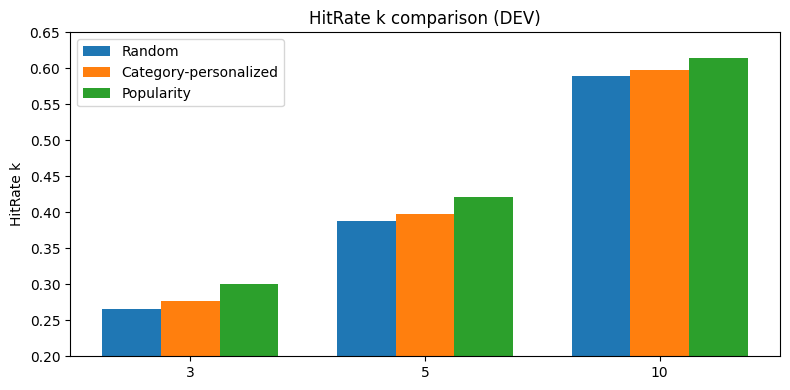

In [74]:
ks = [3, 5, 10]

x = np.arange(len(ks))
w = 0.25

plt.figure(figsize=(8,4))
plt.bar(x - w, hr_rand, width=w, label="Random")
plt.bar(x,     hr_cat,  width=w, label="Category-personalized")
plt.bar(x + w, hr_pop,  width=w, label="Popularity")
plt.xticks(x, [f"{k}" for k in ks])
plt.ylim(0.2, 0.65)
plt.ylabel("HitRate k")
plt.title("HitRate k comparison (DEV)")
plt.legend()
plt.tight_layout()
plt.show()

Across all k, the popularity baseline achieves the highest HitRate@k, meaning it is the most effective at placing clicked items within the top-ranked recommendations. The advantage is clearest for smaller k (HitRate@3 and HitRate@5), which better reflects realistic user attention to the top of the list. Category-based personalization provides a modest improvement over random, but it remains consistently below popularity, suggesting that coarse category preference alone is not sufficient to outperform global popularity on MIND-small.

Random performs relatively well at k=10 because the metric is permissive and impressions contain many candidates, but when focusing on the most visible positions (k=3–5), popularity shows a clearer and consistent advantage, confirming it captures non-trivial signal beyond chance.

### Reinforcement proxy: politics share in top-k recommendations

Now lets measure, for each impression:

- what fraction of the top-k recommended items are politics.

Then compare:

- politically engaged users vs others

- popularity vs personalized baseline

In [78]:
news_dev["is_politics"] = news_dev["subcategory"].str.contains("polit", case=False, na=False)
polit_ids_dev = set(news_dev.loc[news_dev["is_politics"], "news_id"])

def topk_politics_share(score_fn, k=10, max_impressions=20000):
    shares_engaged = []
    shares_other = []

    ids = impression_candidates.index[:max_impressions]
    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]
        scores = np.array([score_fn(imp_id, nid) for nid in cands])
        order = np.argsort(-scores)[:k]
        topk = [cands[i] for i in order]
        share = np.mean([nid in polit_ids_dev for nid in topk])

        if uid in engaged_users:
            shares_engaged.append(share)
        else:
            shares_other.append(share)

    return float(np.mean(shares_engaged)), float(np.mean(shares_other))

eng_pop, oth_pop = topk_politics_share(pop_score_fn, k=10)
eng_cat, oth_cat = topk_politics_share(cat_personal_score_fn, k=10)

pol_pop = [eng_pop, oth_pop]
pol_pers = [ eng_cat, oth_cat]

print("Politics share in Top-10 (Popularity) -> engaged:", eng_pop, "others:", oth_pop)
print("Politics share in Top-10 (Personalized) -> engaged:", eng_cat, "others:", oth_cat)


Politics share in Top-10 (Popularity) -> engaged: 0.04732142857142858 others: 0.02579468709942796
Politics share in Top-10 (Personalized) -> engaged: 0.16436688311688313 others: 0.04862514109701735


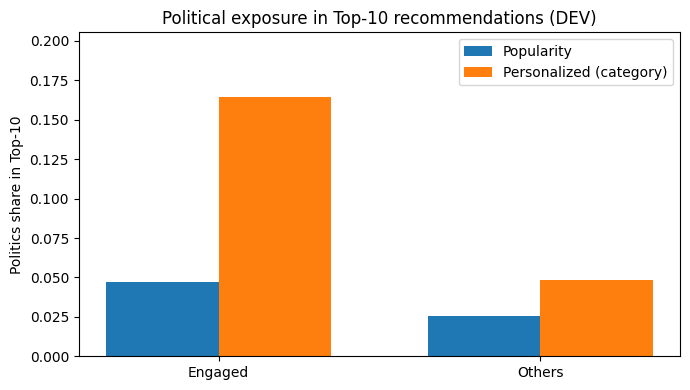

In [76]:
labels = ["Engaged", "Others"]


x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - w/2, pol_pop,  width=w, label="Popularity")
plt.bar(x + w/2, pol_pers, width=w, label="Personalized (category)")
plt.xticks(x, labels)
plt.ylim(0, max(pol_pers) * 1.25)
plt.ylabel("Politics share in Top-10")
plt.title("Political exposure in Top-10 recommendations (DEV)")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation (political exposure in top recommendations):

Under the popularity baseline, political items constitute 4.7% of the top-10 for politically engaged users versus 2.6% for other users, suggesting only a mild difference driven by the candidate pool. In contrast, the category-personalized baseline strongly amplifies political exposure: engaged users receive 16.4% politics in their top-10 compared with 4.9% for other users (≈3.4× higher). This indicates that personalization based on past clicks can substantially increase political content in the most visible recommendation slots for users with prior political engagement, consistent with a reinforcement/echo-chamber mechanism at the ranking stage.

If we use an algorithm that learns from past clicks, it will rank politics higher for political users, and therefore their top-10 recommendations contain more politics.

Can we re-rank to reduce that concentration while keeping accuracy?

### Conclusion (Notebook 04 — Baselines & Offline Evaluation)

This notebook builds two simple ranking baselines using TRAIN click history and evaluates them offline on DEV impressions (the candidate lists that were actually shown to users):

- **Popularity baseline** ranks items by how often they were clicked in TRAIN.
- **Category-personalized baseline** learns a user’s category preferences from TRAIN clicks and ranks DEV candidates accordingly.

### What we learned
1) **Both baselines are better than random**, meaning the training signal contains real information about what users tend to click.
   - The gap is clearer for small k (HitRate@3 and HitRate@5), which better reflects realistic user attention to the top of the list.

2) **Popularity is the strongest accuracy baseline** in this setting.
   - It achieves the best MRR@10, nDCG@10, and HitRate@k among the compared methods.

3) **Personalization strongly changes exposure composition**, even if accuracy is slightly lower.
   - Politically engaged users receive substantially more political content in their Top-10 under personalization than under popularity (and more than non-engaged users).
   - This demonstrates a plausible *reinforcement mechanism*: past political engagement can lead to higher political exposure in future top recommendations.

### Key limitation of this notebook
This is an **offline “what-if” evaluation**: we rank the candidates shown in DEV using simple baselines. It does not directly measure the *temporal loop* in the real platform logs.


### Next (Notebook 05 — Temporal reinforcement in logged feeds)

My original goal is to study the feedback loop through time:

> If a user clicks political content, do the *next* recommendation lists shown to that user contain *more* political content?

Notebook 05 addresses this directly using the DEV logs as a timeline:
- Build an impression-level sequence per user (ordered by timestamp).
- Measure political exposure in impression *t+1* (and further lags) conditioned on what the user clicked in impression *t*.
- Compare the effect for politically engaged users versus others.

This moves from “offline ranking behavior” (Notebook 04) to “observed temporal dynamics” in the logged platform feed (Notebook 05).
